# Residency-3: Project-1 | Supervised Learning | Jayant Ojha

## Problem statement

### Dataset

Campaign for selling personal loans.

This case is about a bank (Thera Bank) which has a growing customer base. Majority of these customers are liability customers (depositors) with varying size of deposits. 
The number of customers who are also borrowers (asset customers) is quite small, and the bank is interested in expanding this base rapidly to bring in more loan business and in the process,
earn more through the interest on loans. In particular, the management wants to explore ways of converting its liability customers to personal loan customers (while retaining them as depositors). 
A campaign that the bank ran last year for liability customers showed a healthy conversion rate of over 9% success. This has encouraged the retail marketing department to devise campaigns with better
 target marketing to increase the success ratio with minimal budget.

The department wants to build a model that will help them identify the potential customers who have higher probability of purchasing the loan. This will increase the success ratio while at the same 
time reduce the cost of the campaign.

**Attributes of the dataset:**
The file Bank_Personal_Loan_Modelling.csv contains data on 5000 customers. The data include customer demographic information (age, income, etc.), the customer's relationship with
 the bank (mortgage, securities account, etc.), and the customer response to the last personal loan campaign (Personal Loan). Among these 5000 customers, only 480 (= 9.6%) accepted the personal loan that
 was offered to them in the earlier campaign.

* Follow the instructions below and create a python notebook to attempt the same :

## Question 1

Read the column description and ensure you understand each attribute well
Study the data distribution in each attribute, share your findings. (5 points)

In [281]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity='all'

In [282]:
import warnings 
warnings.filterwarnings('ignore')

In [283]:
import pandas as pd
import numpy as np

In [284]:
#It is good to start with all the features, & stepwise see:
# 1. The general property of different columns, data types, non-null/null, distributions etc
# 2. Do a transformation if required (i.e. Categorical to Onehot etc)
# 3. if there is any strong corelation across the feature-set.Good to drop the features 
#    which are strongly correlated (one of them).
customer_df = pd.read_csv("./Bank_Personal_Loan_Modelling.csv")

In [285]:
customer_df.head()

,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,1,25,1,49,91107,4,1.60,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.50,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1.00,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.70,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.00,2,0,0,0,0,0,1


In [286]:
#the "ID" can be taken as index for the dataframe, rather than being a feature.
customer_df = customer_df.set_index('ID') 

In [287]:
customer_df.head()

,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
ID,,,,,,,,,,,,,
1,25,1,49,91107,4,1.60,1,0,0,1,0,0,0
2,45,19,34,90089,3,1.50,1,0,0,1,0,0,0
3,39,15,11,94720,1,1.00,1,0,0,0,0,0,0
4,35,9,100,94112,1,2.70,2,0,0,0,0,0,0
5,35,8,45,91330,4,1.00,2,0,0,0,0,0,1


In [288]:
customer_df.shape

(5000, 13)

In [289]:
#Based on the "info", all the features are appearing quantitative with no-null values.
#But, the issue with features like "Zip Code" is that we should not take the int64
#values appearing for them, that will be problematic for models if consumed straigtaway
#as numerical value. Below, will have to transform this "high cardinality" feature to a
#"Supervised Ratio" so as #to be relevant to the 1s and 0s of the Response 
#variable ("Personal Loan")
customer_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 5000 entries, 1 to 5000
Data columns (total 13 columns):
Age                   5000 non-null int64
Experience            5000 non-null int64
Income                5000 non-null int64
ZIP Code              5000 non-null int64
Family                5000 non-null int64
CCAvg                 5000 non-null float64
Education             5000 non-null int64
Mortgage              5000 non-null int64
Personal Loan         5000 non-null int64
Securities Account    5000 non-null int64
CD Account            5000 non-null int64
Online                5000 non-null int64
CreditCard            5000 non-null int64
dtypes: float64(1), int64(12)
memory usage: 546.9 KB


In [290]:
#routine to transform a "high cardinality" feature into a "supervised ratio" weight
#as illustrated here: https://www.kdnuggets.com/2016/08/include-high-cardinality-attributes-predictive-model.html
#Supervised ratio: the easiest transformation is transforming each ZIP code to the percentage of positive
#instances in that ZIP code. When predicting churn for example, a person whose ZIP code is 10009 will be given a 
#transformed value of the percentage of churners in that ZIP code. So if the training set consists of 100 customers
#in ZIP code 10009, 5 of which churned (so Pi=5 and Ni=95) then the transformed value is 0.05. The intuitive nature
#of the variable makes it very suitable for subsequent use in decision trees and rules.
def transform_high_cardinal_category(df, HC_feature, Response):
    #set options for float values(2 places after decimal point)
    pd.options.display.float_format = '{:,.2f}'.format
    #Group the dataframe by "Zip Code"(or the "High Cardinality" HC-feature)
    #and on the "Response" column (i.e. "Personal Loan" in this case) 
    #calculate the sum (i.e. number of times 1 appears for a zipcode)
    #and also the count(i.e. the total entries of "personal loan" undera
    #zipcode)
    #Finally, the elements of the "feature-to-be-transformed" can be
    #given values: sum/count
    group_df = df.groupby(HC_feature)[Response].agg(["count","sum"])
    group_df.reset_index(inplace=True)
    df[HC_feature] = [float((group_df.loc[group_df[HC_feature]==x]['sum']/group_df.loc[group_df[HC_feature]==x]['count']).values) for x in df[HC_feature]]
    return df

In [291]:
#Now call the above routine, with the original dataframe, The feature to be transformed(i.e. "Zip Code")
# and the "response variable" ("personal loan" in this case)
new_customer_df = transform_high_cardinal_category(customer_df, "ZIP Code", "Personal Loan")

In [292]:
new_customer_df.sample(n=8, random_state=2)

,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
ID,,,,,,,,,,,,,
3567,57,33,80,0.08,2,2.80,1,0,0,0,0,1,1
4253,54,29,81,0.12,1,0.10,3,0,0,0,0,0,0
1919,39,9,118,0.09,2,6.00,3,246,1,0,1,1,1
4112,43,17,21,0.00,3,1.50,1,0,0,0,0,0,0
1472,52,26,180,0.10,1,1.00,1,0,0,0,0,1,1
930,55,30,22,0.07,1,1.50,2,91,0,0,0,0,1
1917,57,32,64,0.29,3,1.60,3,0,0,0,0,1,0
3996,53,28,34,0.11,2,0.60,3,0,0,0,0,1,1


In [293]:
new_customer_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 5000 entries, 1 to 5000
Data columns (total 13 columns):
Age                   5000 non-null int64
Experience            5000 non-null int64
Income                5000 non-null int64
ZIP Code              5000 non-null float64
Family                5000 non-null int64
CCAvg                 5000 non-null float64
Education             5000 non-null int64
Mortgage              5000 non-null int64
Personal Loan         5000 non-null int64
Securities Account    5000 non-null int64
CD Account            5000 non-null int64
Online                5000 non-null int64
CreditCard            5000 non-null int64
dtypes: float64(2), int64(11)
memory usage: 706.9 KB


In [294]:
from matplotlib import pyplot
import seaborn as sns
%matplotlib inline

In [295]:
#We need to have a look into the "descriptive stats" for individual feature distributions
#as follows...followed by a pairplot first and an indivudal histograms later.
new_customer_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,"5,000.00",45.34,11.46,23.00,35.00,45.00,55.00,67.00
Experience,"5,000.00",20.10,11.47,-3.00,10.00,20.00,30.00,43.00
Income,"5,000.00",73.77,46.03,8.00,39.00,64.00,98.00,224.00
ZIP Code,"5,000.00",0.10,0.09,0.00,0.00,0.09,0.14,0.67
Family,"5,000.00",2.40,1.15,1.00,1.00,2.00,3.00,4.00
CCAvg,"5,000.00",1.94,1.75,0.00,0.70,1.50,2.50,10.00
Education,"5,000.00",1.88,0.84,1.00,1.00,2.00,3.00,3.00
Mortgage,"5,000.00",56.50,101.71,0.00,0.00,0.00,101.00,635.00
Personal Loan,"5,000.00",0.10,0.29,0.00,0.00,0.00,0.00,1.00
Securities Account,"5,000.00",0.10,0.31,0.00,0.00,0.00,0.00,1.00


**From the above descriptive-statistics summary and also from the histogram for the "Experience" feature below**

*It appears there are some -ve values, which should be converted to "mean/median" in this case the mean and median are same, dont think that it can be made 0*

In [296]:
#For ploting the "individual" detailed spread of the histogram, the follwoing function
#is being written...here, default "cut-points" value is 40, & all the "quant" features (which actually are, all of them)
#are selected by using the "describe", without the "all" option, dataframe.Then we loop thru individual feature, and the 
#feature-min to feature-max is divided into the cut-points (default 40) & plotted in turn.
#Many of the features show outliers (even on a z-score, seen separtely as in a follwing cell, the values go above z= +3.0)
#but we don't worry about the "outlier-tails" (as yet....some dist-transformaiton techniques
# would be required later though)
def show_quant_feature_hist_plot(df, cut_pts=40, fig_height=15, fig_len=20):
    #defaul
    descr_trans_df = df.describe()
    for feature in list(descr_trans_df.T.index):
        bins = np.linspace(descr_trans_df[feature]['min'], descr_trans_df[feature]['max'], cut_pts)
        pyplot.subplots(figsize=(fig_len,fig_height))
        #pyplot.hist(df[feature], bins, alpha=0.5, normed=True, label=str(feature)) 
        pyplot.hist(df[feature], bins, alpha=0.5, label=str(feature))
        pyplot.legend(loc='upper right')
        pyplot.show()

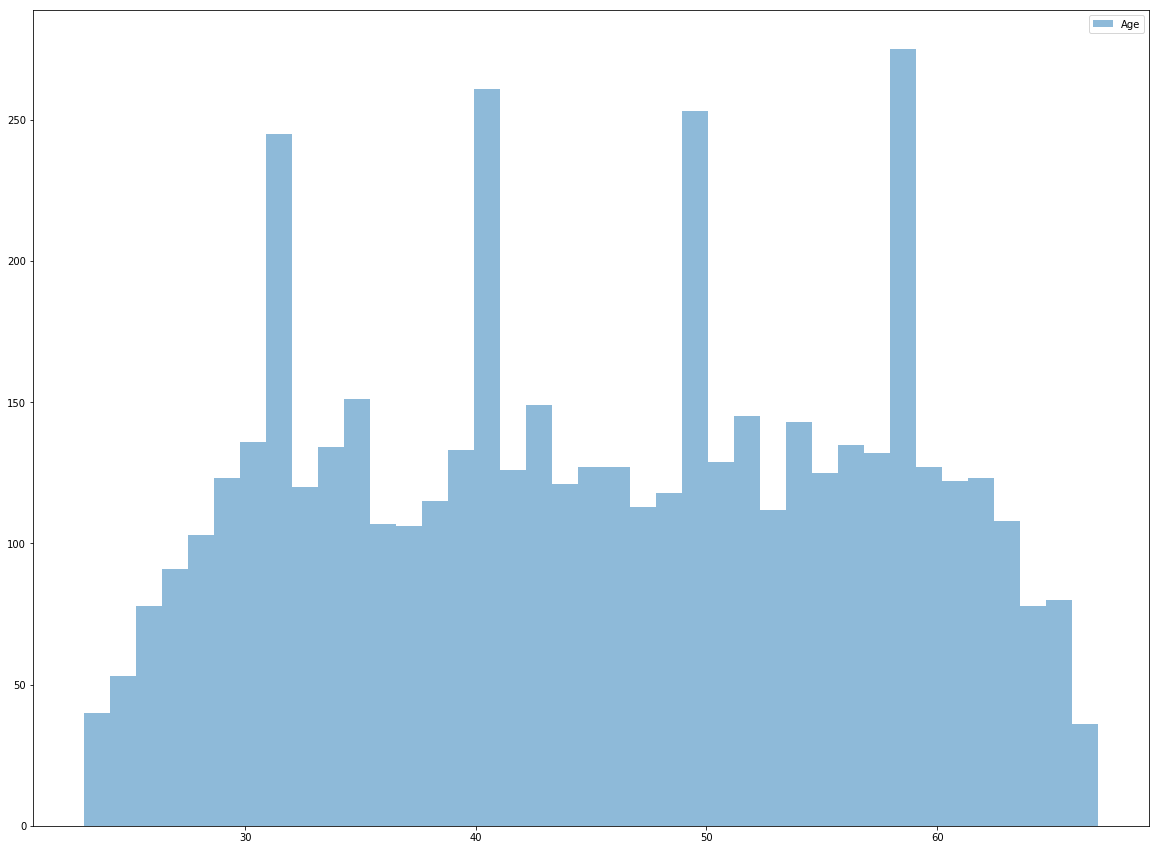

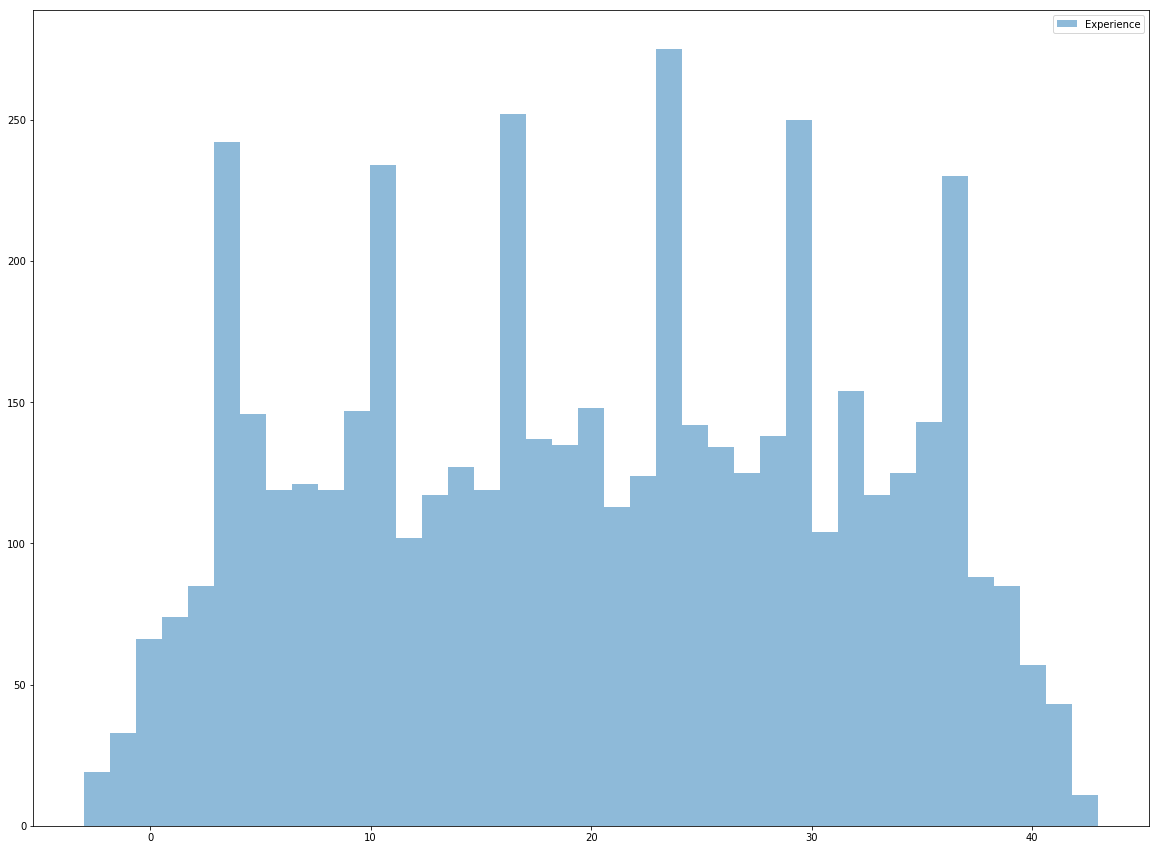

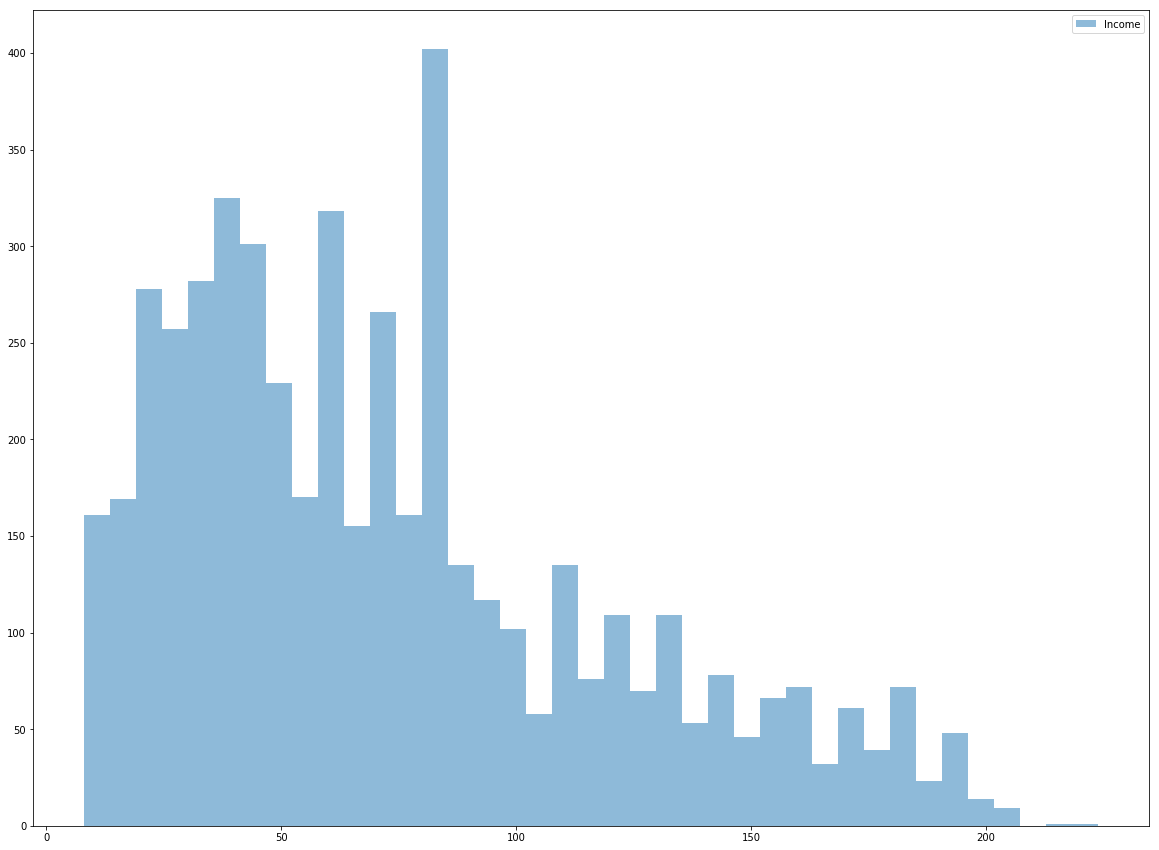

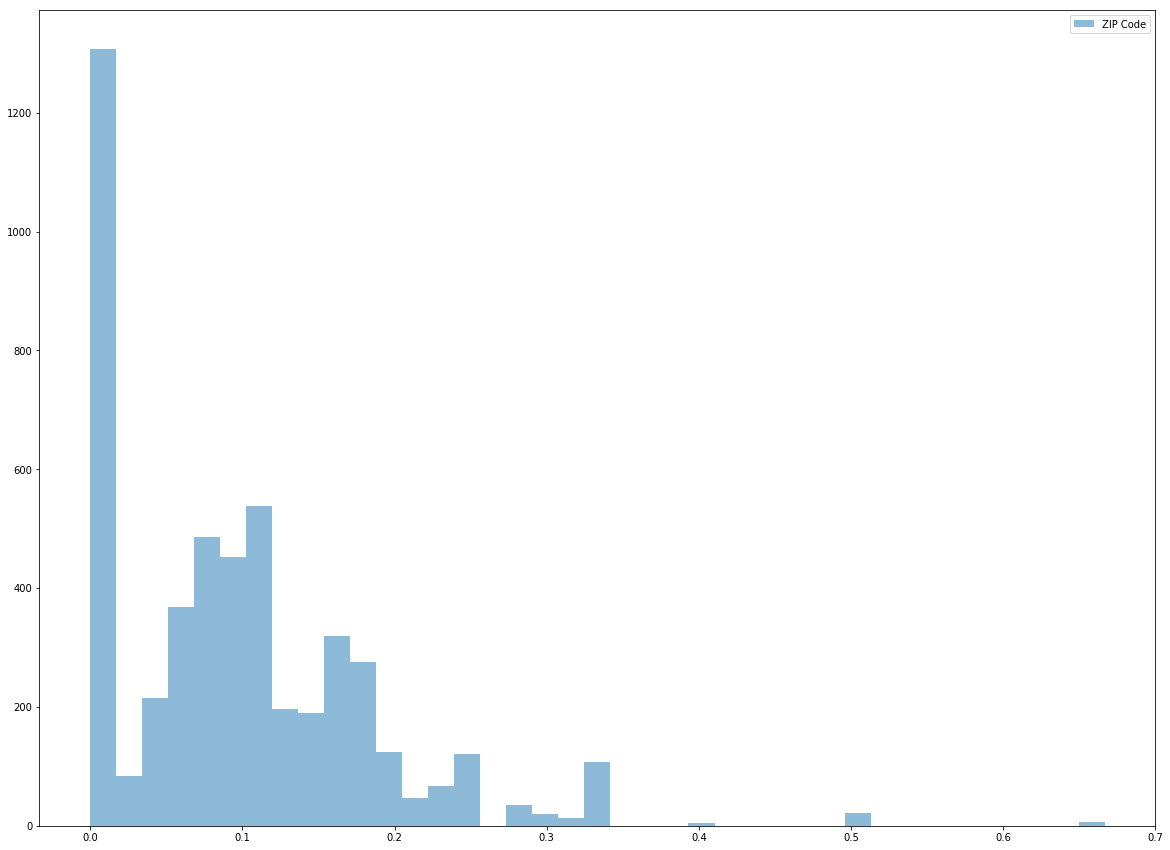

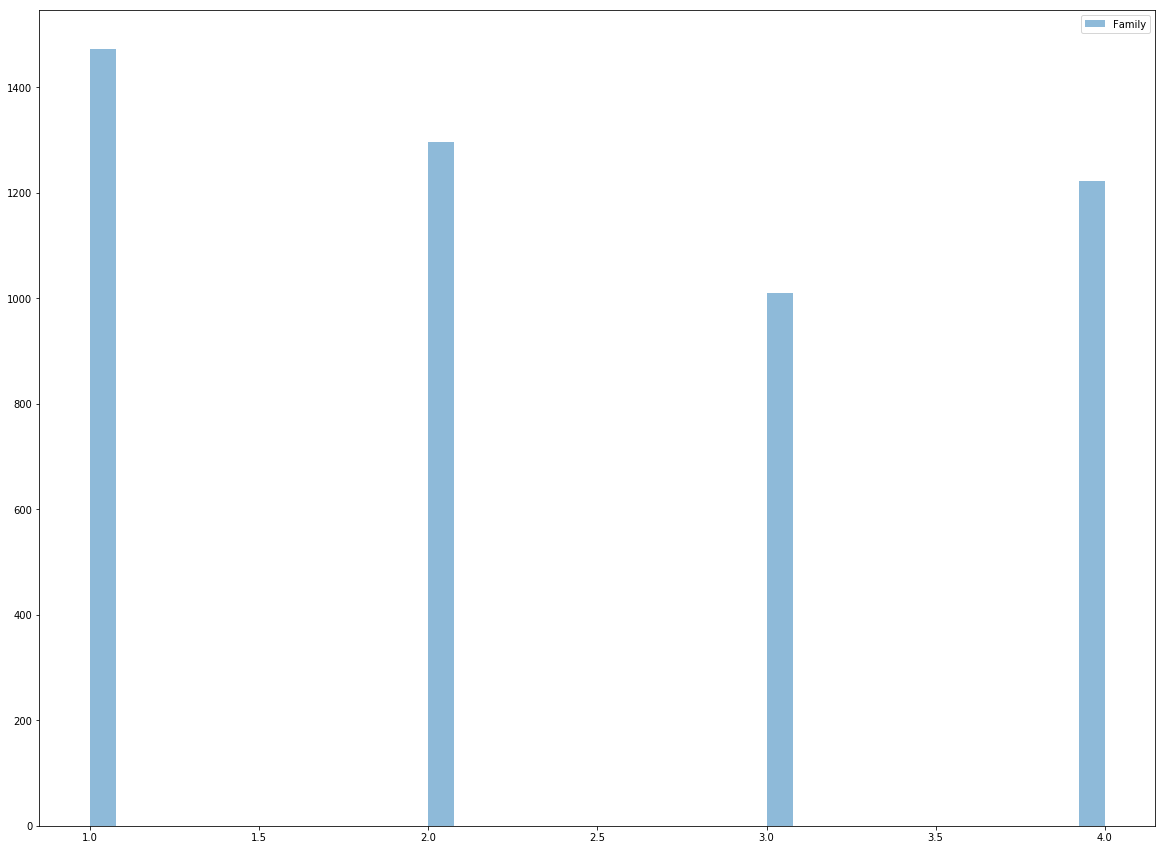

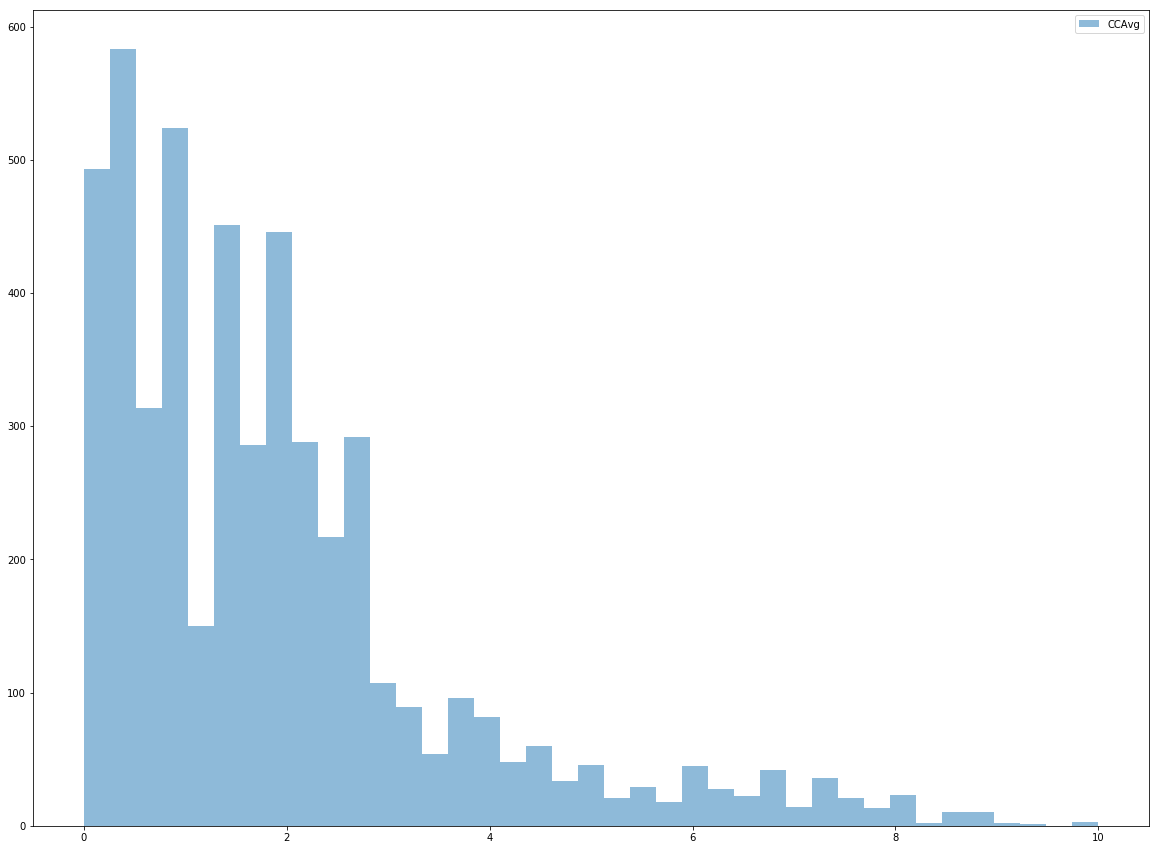

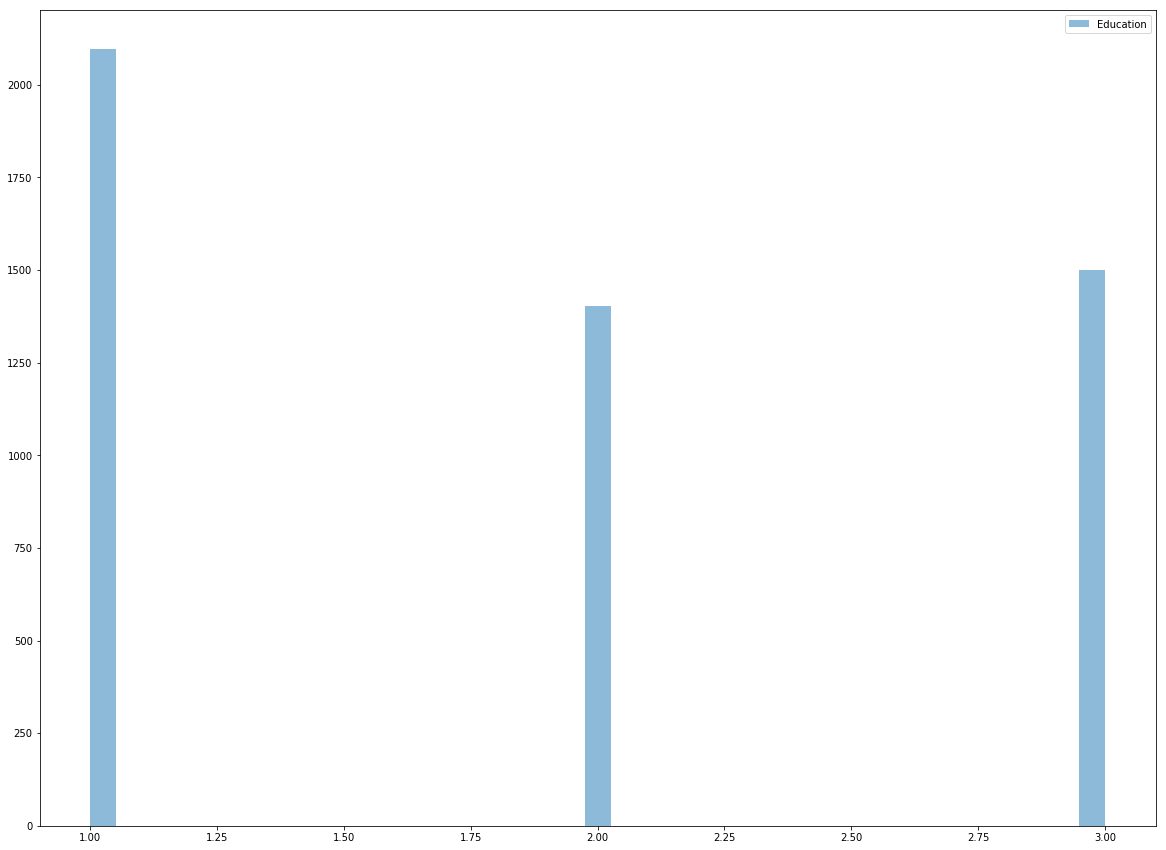

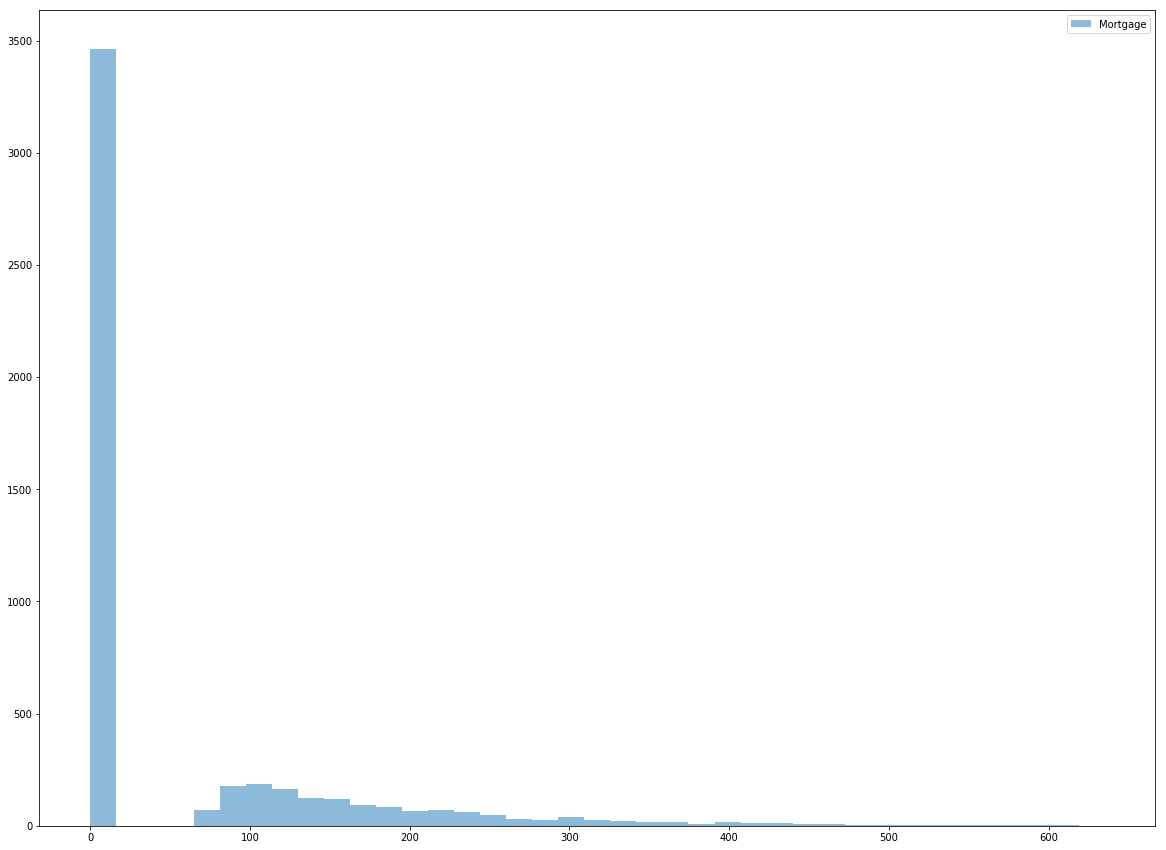

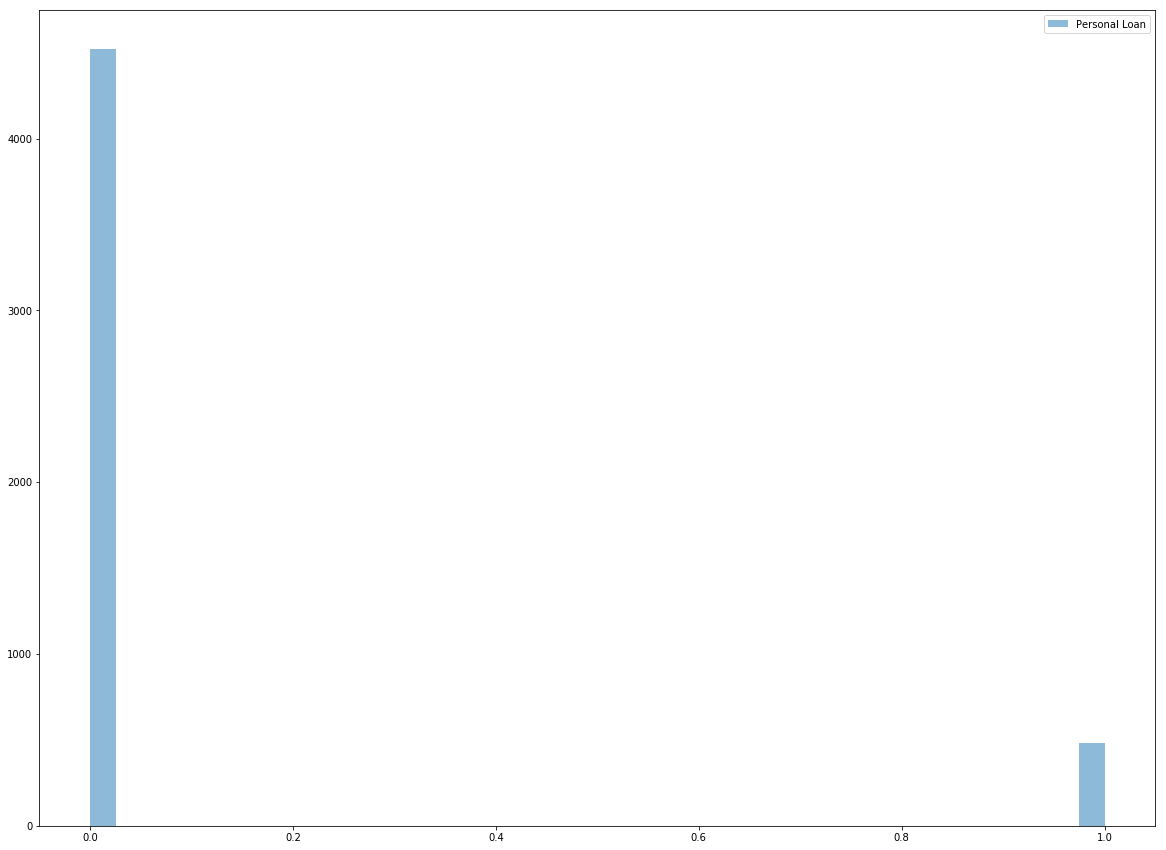

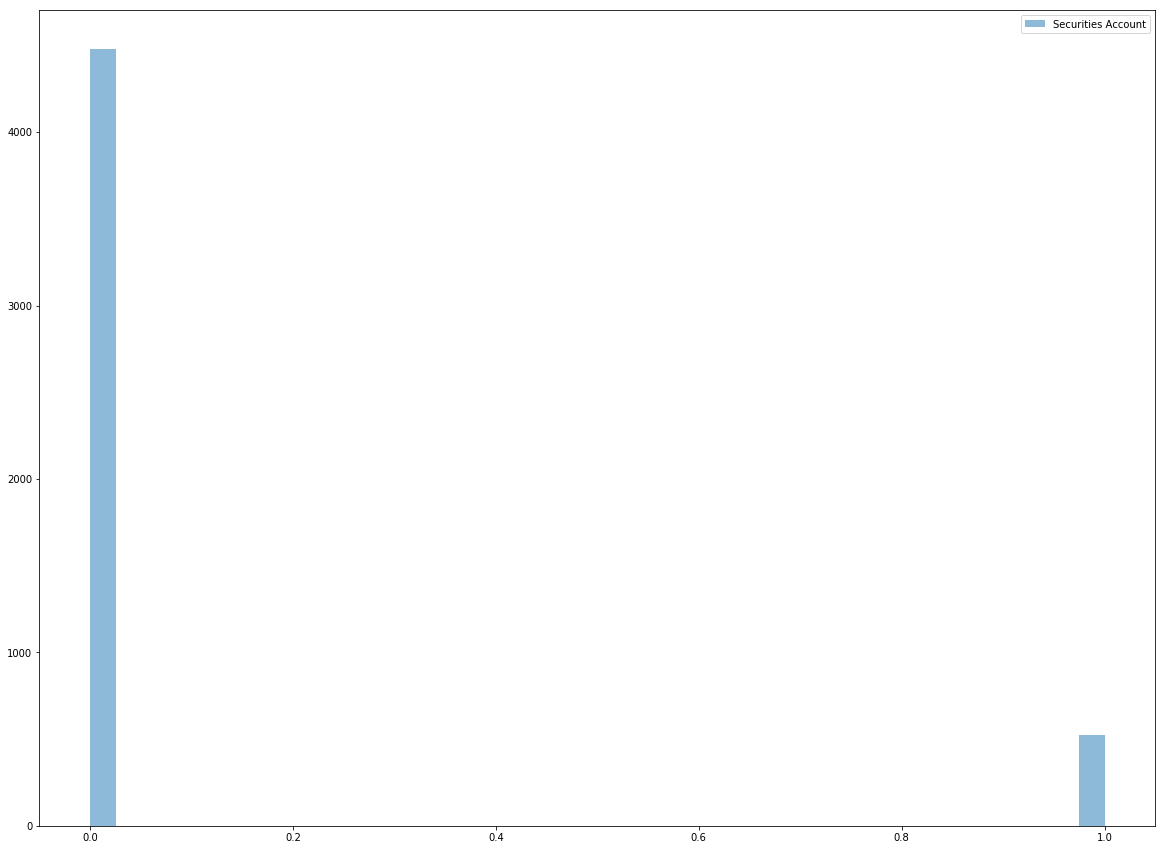

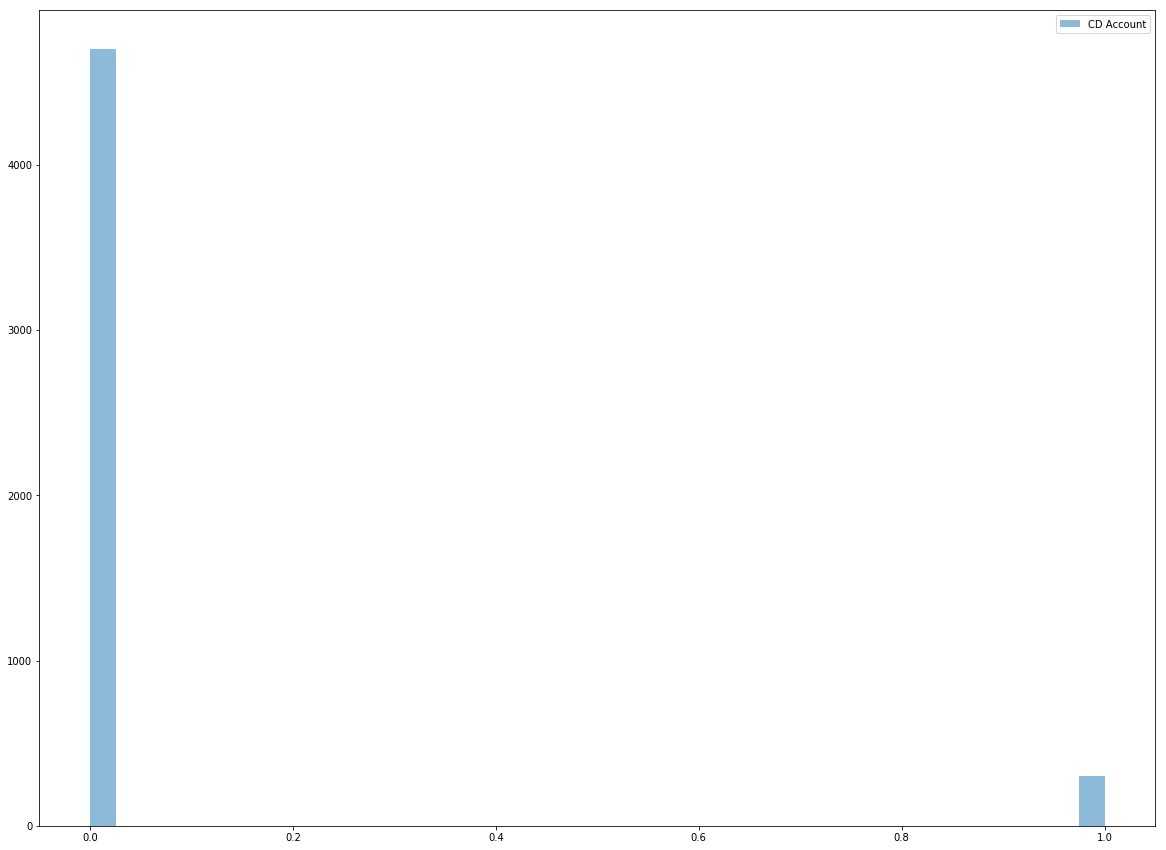

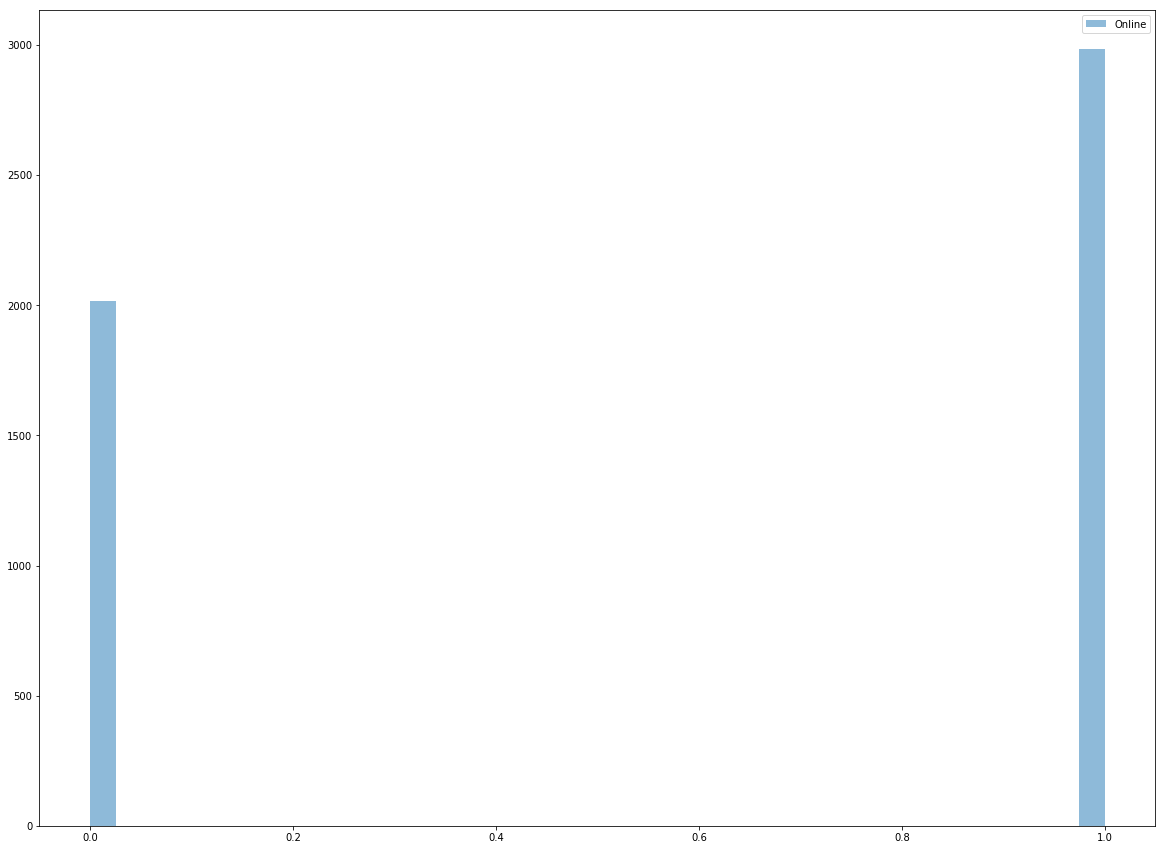

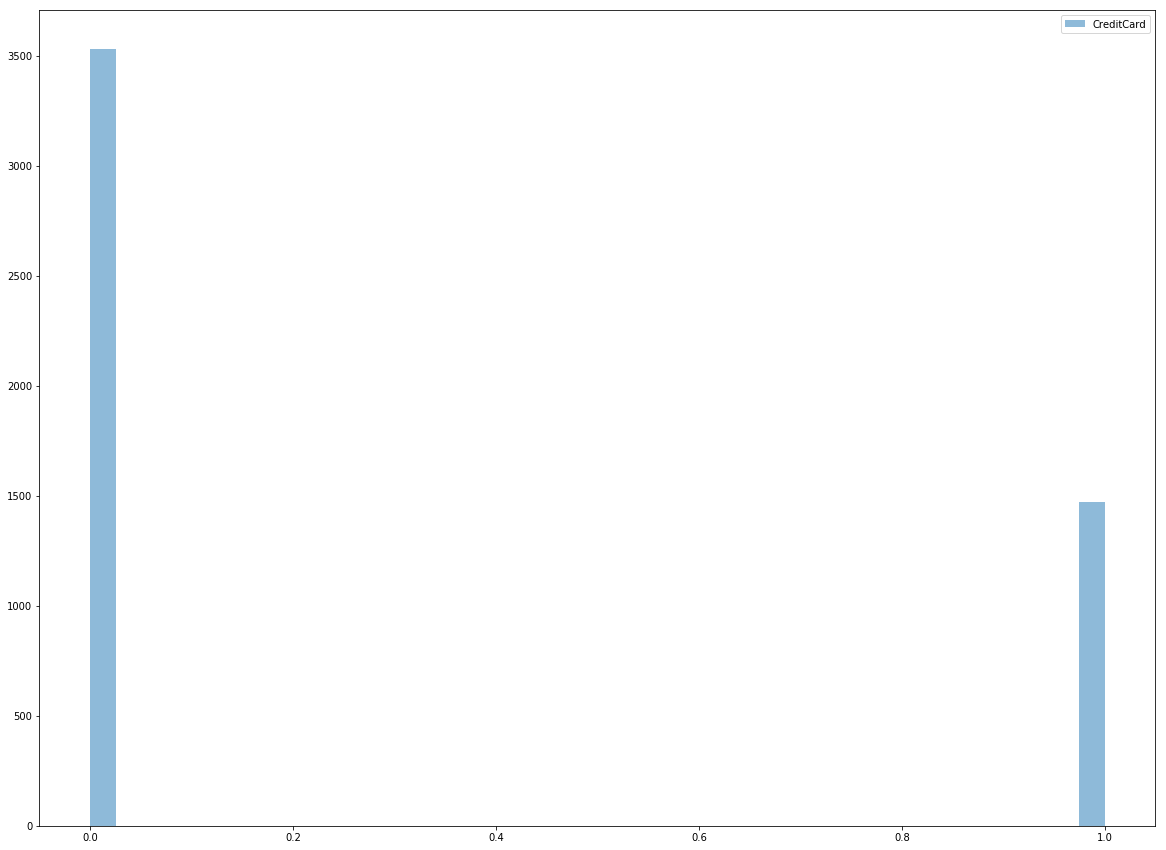

In [297]:
#Now call this function on the original dataframe above
show_quant_feature_hist_plot(new_customer_df)

**The below plots (after z-score transformation, is an attempt to see if there are outliers present**

*many of these features(like Zip-Code, CCAvg actually show outliers (z-score > +3.0), which may require some removal before
feeding them to the models like LR, KNN & NB??...but for this excercise, it seems out of scope*

Text(0.5, 1.0, 'Before Scaling')

Text(0.5, 1.0, 'After Standard Scaler')

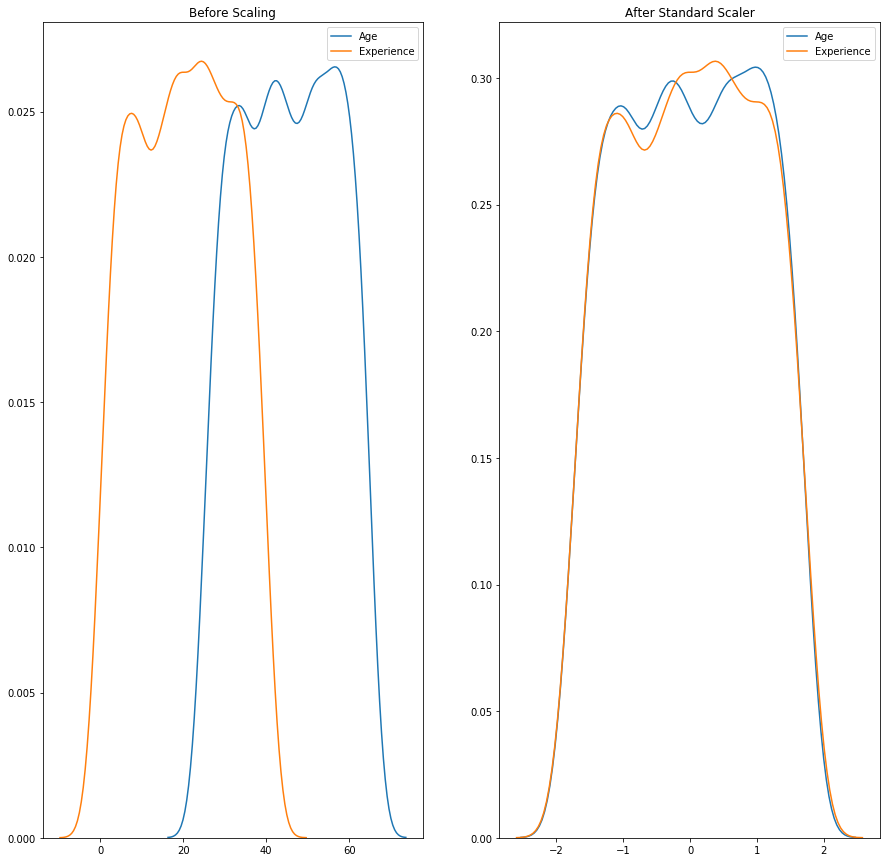

In [298]:
# The result on the z-score (standardScalar transform) can also be looked at
# which can be used to ascertain outliers (thumb rule: z score beyond +/-3.0 values)...
# but we don't worry about the "outlier-tails" (as yet....some dist-transformaiton techniques
# would be required later though)
from sklearn import preprocessing
descr_trans_df = new_customer_df.describe()
scaler = preprocessing.StandardScaler()
scaled_X = scaler.fit_transform(new_customer_df[list(descr_trans_df.T.index)])
scaled_X = pd.DataFrame(scaled_X, columns=list(descr_trans_df.T.index))
fig, (ax1, ax2) = pyplot.subplots(ncols=2, figsize=(15, 15))
ax1.set_title('Before Scaling')
for i in list(descr_trans_df.T.index)[0:2]:
    sns.kdeplot(new_customer_df[i], ax=ax1)
ax2.set_title('After Standard Scaler')
for i in list(descr_trans_df.T.index)[0:2]:
    sns.kdeplot(scaled_X[i], ax=ax2)
pyplot.show()

Text(0.5, 1.0, 'Before Scaling')

Text(0.5, 1.0, 'After Standard Scaler')

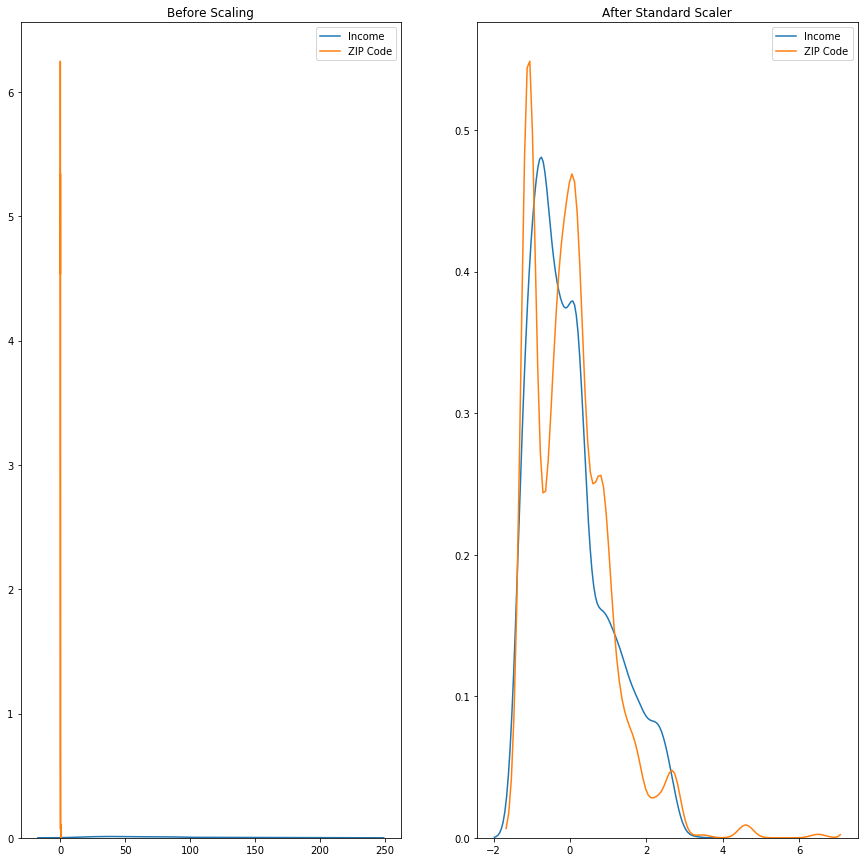

In [299]:
# The result on the z-score (standardScalar transform) can also be looked at
# which can be used to ascertain outliers (thumb rule: z score beyond +/-3.0 values)...
# but we don't worry about the "outlier-tails" (as yet....some dist-transformaiton techniques
# would be required later though)
from sklearn import preprocessing
descr_trans_df = new_customer_df.describe()
scaler = preprocessing.StandardScaler()
scaled_X = scaler.fit_transform(new_customer_df[list(descr_trans_df.T.index)])
scaled_X = pd.DataFrame(scaled_X, columns=list(descr_trans_df.T.index))
fig, (ax1, ax2) = pyplot.subplots(ncols=2, figsize=(15, 15))
ax1.set_title('Before Scaling')
for i in list(descr_trans_df.T.index)[2:4]:
    sns.kdeplot(new_customer_df[i], ax=ax1)
ax2.set_title('After Standard Scaler')
for i in list(descr_trans_df.T.index)[2:4]:
    sns.kdeplot(scaled_X[i], ax=ax2)
pyplot.show()

Text(0.5, 1.0, 'Before Scaling')

Text(0.5, 1.0, 'After Standard Scaler')

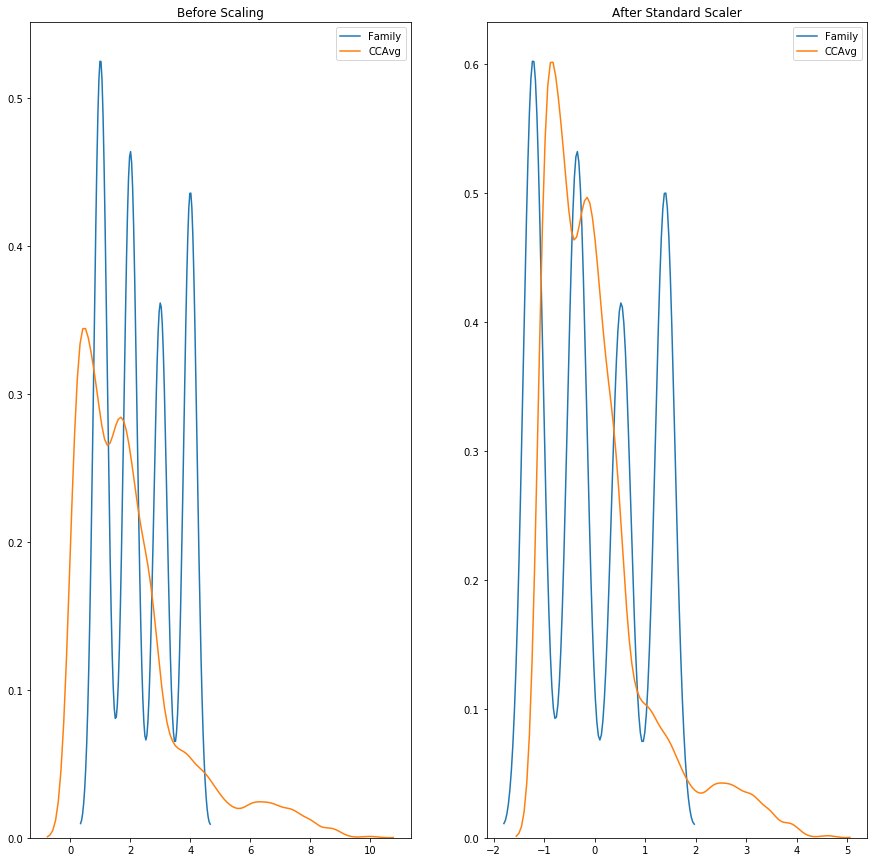

In [300]:
# The result on the z-score (standardScalar transform) can also be looked at
# which can be used to ascertain outliers (thumb rule: z score beyond +/-3.0 values)...
# but we don't worry about the "outlier-tails" (as yet....some dist-transformaiton techniques
# would be required later though)
from sklearn import preprocessing
descr_trans_df = new_customer_df.describe()
scaler = preprocessing.StandardScaler()
scaled_X = scaler.fit_transform(new_customer_df[list(descr_trans_df.T.index)])
scaled_X = pd.DataFrame(scaled_X, columns=list(descr_trans_df.T.index))
fig, (ax1, ax2) = pyplot.subplots(ncols=2, figsize=(15, 15))
ax1.set_title('Before Scaling')
for i in list(descr_trans_df.T.index)[4:6]:
    sns.kdeplot(new_customer_df[i], ax=ax1)
ax2.set_title('After Standard Scaler')
for i in list(descr_trans_df.T.index)[4:6]:
    sns.kdeplot(scaled_X[i], ax=ax2)
pyplot.show()

Text(0.5, 1.0, 'Before Scaling')

Text(0.5, 1.0, 'After Standard Scaler')

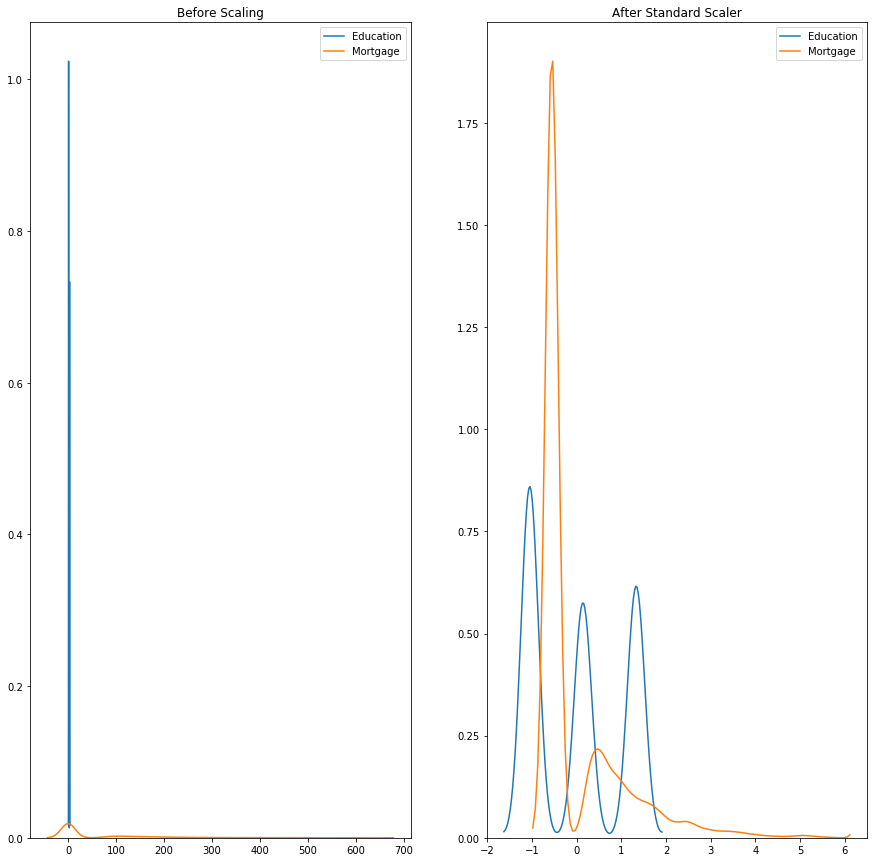

In [301]:
# The result on the z-score (standardScalar transform) can also be looked at
# which can be used to ascertain outliers (thumb rule: z score beyond +/-3.0 values)...
# but we don't worry about the "outlier-tails" (as yet....some dist-transformaiton techniques
# would be required later though)
from sklearn import preprocessing
descr_trans_df = new_customer_df.describe()
scaler = preprocessing.StandardScaler()
scaled_X = scaler.fit_transform(new_customer_df[list(descr_trans_df.T.index)])
scaled_X = pd.DataFrame(scaled_X, columns=list(descr_trans_df.T.index))
fig, (ax1, ax2) = pyplot.subplots(ncols=2, figsize=(15, 15))
ax1.set_title('Before Scaling')
for i in list(descr_trans_df.T.index)[6:8]:
    sns.kdeplot(new_customer_df[i], ax=ax1)
ax2.set_title('After Standard Scaler')
for i in list(descr_trans_df.T.index)[6:8]:
    sns.kdeplot(scaled_X[i], ax=ax2)
pyplot.show()

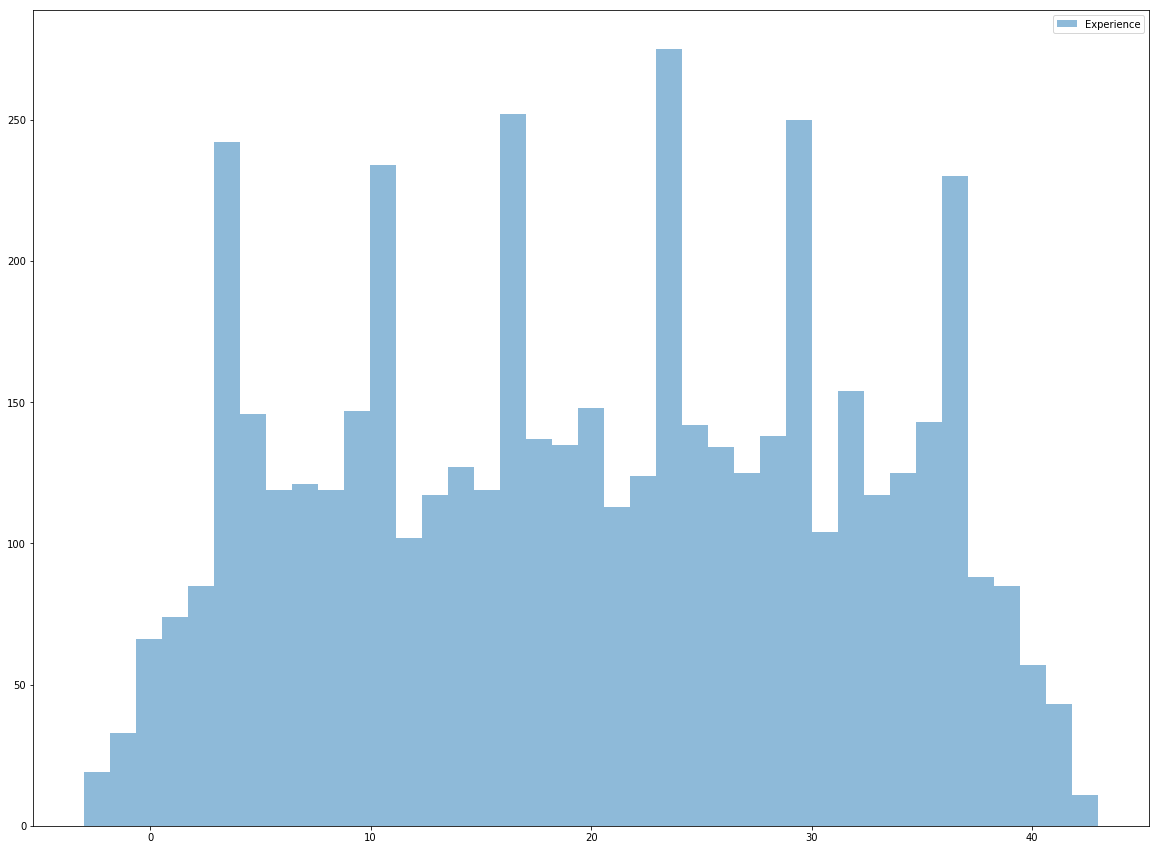

In [302]:
#We can addiitonally see the "Experience" distribution alone visually, as a "before" scenario
show_quant_feature_hist_plot(new_customer_df[["Experience"]])

In [303]:
#replace the -ve values in "Experience" feature to mean for the same column( the distribution will remain unaffeted
#by this change, as shown above in the histogram and descriptve-stats)
new_customer_df["Experience"] = np.where(new_customer_df["Experience"]<0, new_customer_df["Experience"].mean(), new_customer_df["Experience"])

In [304]:
new_customer_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,"5,000.00",45.34,11.46,23.00,35.00,45.00,55.00,67.00
Experience,"5,000.00",20.33,11.25,0.00,11.00,20.10,30.00,43.00
Income,"5,000.00",73.77,46.03,8.00,39.00,64.00,98.00,224.00
ZIP Code,"5,000.00",0.10,0.09,0.00,0.00,0.09,0.14,0.67
Family,"5,000.00",2.40,1.15,1.00,1.00,2.00,3.00,4.00
CCAvg,"5,000.00",1.94,1.75,0.00,0.70,1.50,2.50,10.00
Education,"5,000.00",1.88,0.84,1.00,1.00,2.00,3.00,3.00
Mortgage,"5,000.00",56.50,101.71,0.00,0.00,0.00,101.00,635.00
Personal Loan,"5,000.00",0.10,0.29,0.00,0.00,0.00,0.00,1.00
Securities Account,"5,000.00",0.10,0.31,0.00,0.00,0.00,0.00,1.00


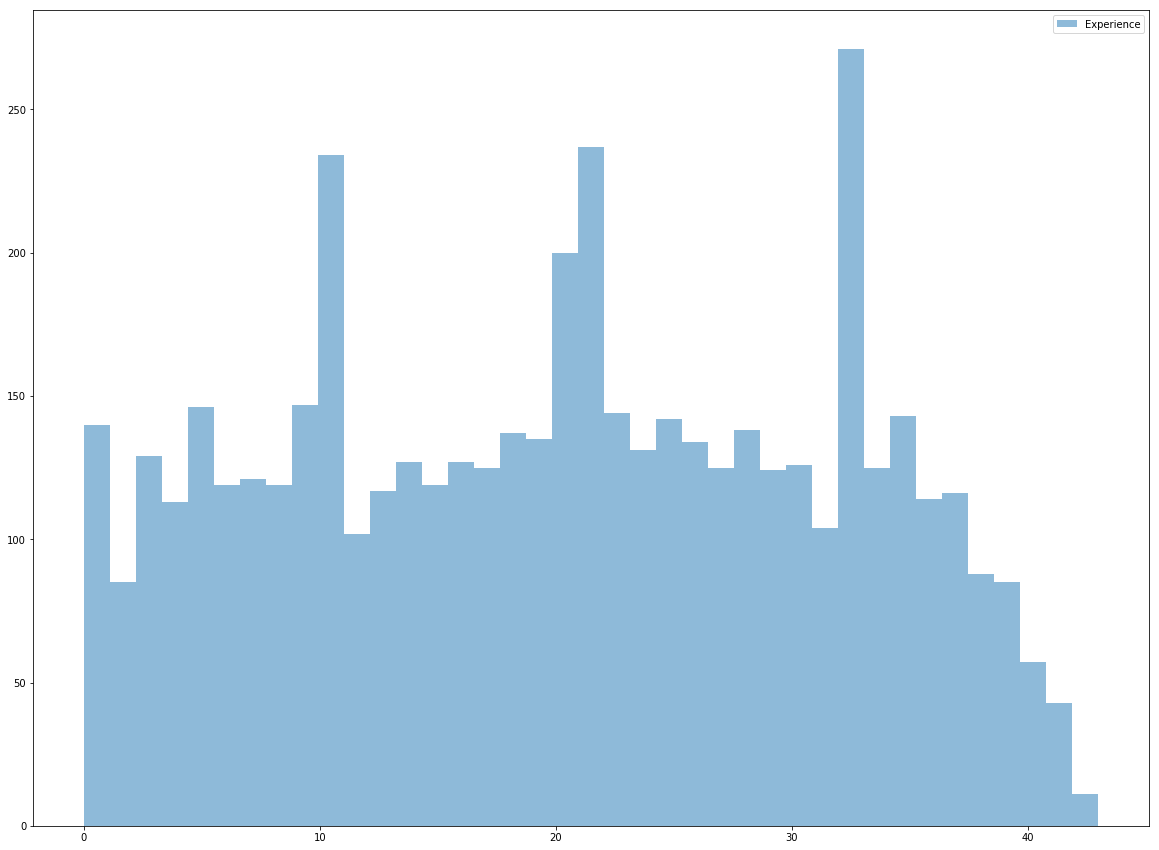

In [305]:
#We can addiitonally see the "Experience" distribution alone visually, to see the removal of negatives.
show_quant_feature_hist_plot(new_customer_df[["Experience"]])

**Next item to focus on is the presence of highly correlated features and removal of the ones > 0.95**

(<Figure size 1440x1080 with 1 Axes>,
 <matplotlib.axes._subplots.AxesSubplot at 0x21f74232e10>)

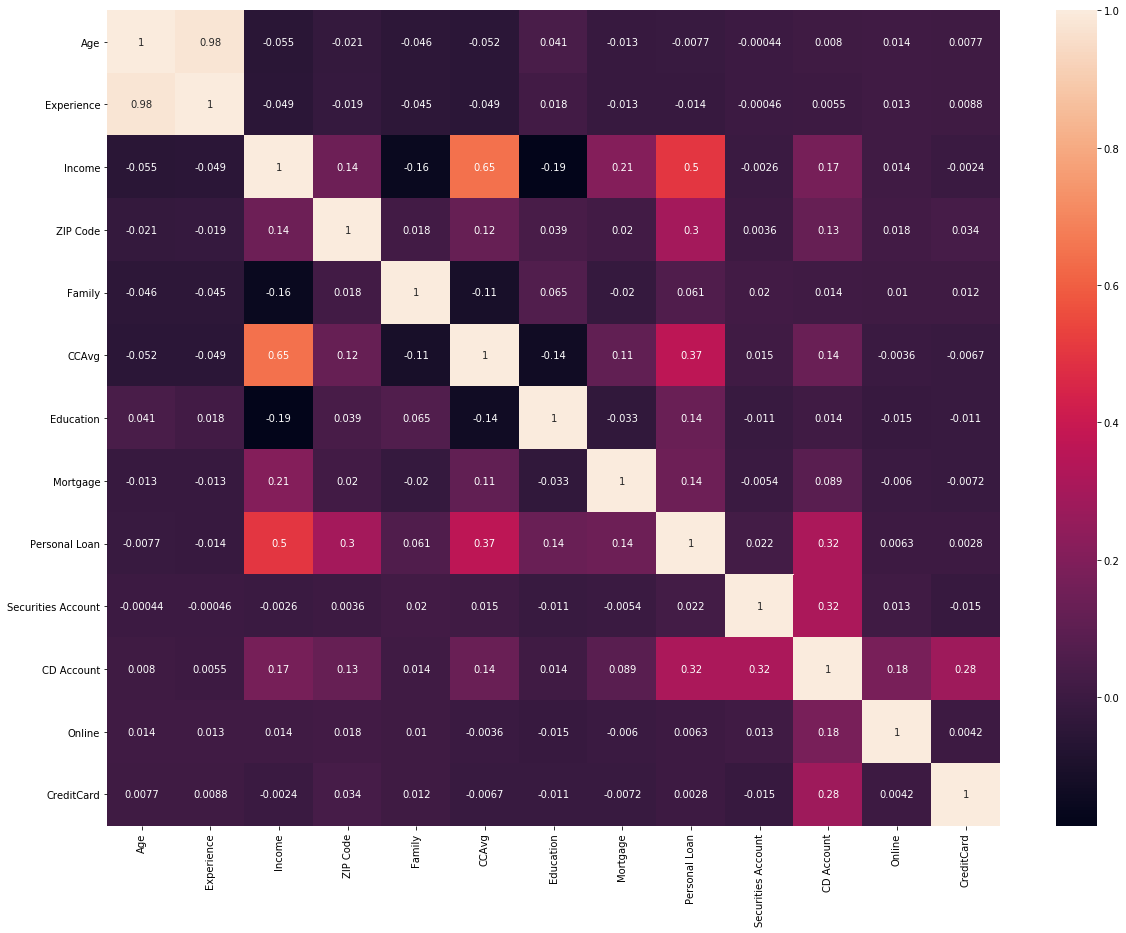

In [306]:
#Now it is required to get a visual sense of the correlation matrix to find the 
#highly correlated "almost white patches" of features (i.e. candidates to be dropped)
#later it can be dropped thru code using a fixed criteria of say (>0.95 or >0.93 etc)
pyplot.subplots(figsize=(20,15))
sns.heatmap(new_customer_df.corr(), annot=True)

In [307]:
#Though visually we can remove the "Experince" (as it his highly correlated with "Age")
#but here in the next few steps(cells), is the code to drop that formally.
col_name_full = list(new_customer_df.T.index)

In [308]:
col_name_full

['Age',
 'Experience',
 'Income',
 'ZIP Code',
 'Family',
 'CCAvg',
 'Education',
 'Mortgage',
 'Personal Loan',
 'Securities Account',
 'CD Account',
 'Online',
 'CreditCard']

In [309]:
# Create correlation matrix with all strongly correlated values (i.e. both -ve and +ve
# values converted to absolute counterparts so as to compare with a thresold like 0.95)
corr_matrix = new_customer_df.corr().abs()
corr_matrix

,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
Age,1.00,0.98,0.06,0.02,0.05,0.05,0.04,0.01,0.01,0.00,0.01,0.01,0.01
Experience,0.98,1.00,0.05,0.02,0.05,0.05,0.02,0.01,0.01,0.00,0.01,0.01,0.01
Income,0.06,0.05,1.00,0.14,0.16,0.65,0.19,0.21,0.50,0.00,0.17,0.01,0.00
ZIP Code,0.02,0.02,0.14,1.00,0.02,0.12,0.04,0.02,0.30,0.00,0.13,0.02,0.03
Family,0.05,0.05,0.16,0.02,1.00,0.11,0.06,0.02,0.06,0.02,0.01,0.01,0.01
CCAvg,0.05,0.05,0.65,0.12,0.11,1.00,0.14,0.11,0.37,0.02,0.14,0.00,0.01
Education,0.04,0.02,0.19,0.04,0.06,0.14,1.00,0.03,0.14,0.01,0.01,0.02,0.01
Mortgage,0.01,0.01,0.21,0.02,0.02,0.11,0.03,1.00,0.14,0.01,0.09,0.01,0.01
Personal Loan,0.01,0.01,0.50,0.30,0.06,0.37,0.14,0.14,1.00,0.02,0.32,0.01,0.00
Securities Account,0.00,0.00,0.00,0.00,0.02,0.02,0.01,0.01,0.02,1.00,0.32,0.01,0.02


In [310]:
#Now using the Datframe.where() method, we replace all the elements of this corr_matrix,
#which are "on-or-below" the main digonal to NaNs, while retaining the original absolute values
#on the "upper-triangle" of the correlation-matrix (i.e. only one set of value on upper or lower triangles
#represents all the possible correlation values)
upper= corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(np.bool))
upper

,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
Age,nan,0.98,0.06,0.02,0.05,0.05,0.04,0.01,0.01,0.00,0.01,0.01,0.01
Experience,nan,nan,0.05,0.02,0.05,0.05,0.02,0.01,0.01,0.00,0.01,0.01,0.01
Income,nan,nan,nan,0.14,0.16,0.65,0.19,0.21,0.50,0.00,0.17,0.01,0.00
ZIP Code,nan,nan,nan,nan,0.02,0.12,0.04,0.02,0.30,0.00,0.13,0.02,0.03
Family,nan,nan,nan,nan,nan,0.11,0.06,0.02,0.06,0.02,0.01,0.01,0.01
CCAvg,nan,nan,nan,nan,nan,nan,0.14,0.11,0.37,0.02,0.14,0.00,0.01
Education,nan,nan,nan,nan,nan,nan,nan,0.03,0.14,0.01,0.01,0.02,0.01
Mortgage,nan,nan,nan,nan,nan,nan,nan,nan,0.14,0.01,0.09,0.01,0.01
Personal Loan,nan,nan,nan,nan,nan,nan,nan,nan,nan,0.02,0.32,0.01,0.00
Securities Account,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,0.32,0.01,0.02


In [311]:
# Find index of feature columns with correlation greater than 0.95
#we get a "list" of features which can be dropped.
to_drop = [column for column in upper.columns if any(upper[column] > 0.95)]
print(to_drop)

['Experience']


**We can see that "Experince" appears in the list of to-be-dropped**

In [312]:
#and from the above we can filter out the "remaining" feature set from
#the original "col_names_full"
new_colnames = [x for x in col_name_full if x not in to_drop]
new_colnames

['Age',
 'Income',
 'ZIP Code',
 'Family',
 'CCAvg',
 'Education',
 'Mortgage',
 'Personal Loan',
 'Securities Account',
 'CD Account',
 'Online',
 'CreditCard']

In [313]:
#Thus we can see below, that out of the 12 original features, 1 got dropped
#leaving 1 features behind.(personal loan is appearing below as extra...but is not feature, it is the response)
len(col_name_full)
len(to_drop)
len(new_colnames)

13

1

12

In [314]:
#Thus the "new" customer Dataframe which can be used is as follows:
new_customer_df = new_customer_df.loc[:,new_colnames]
#preserve the above(deep copy) in a dataframe for separate use later
orig_new_customer_df = new_customer_df.copy()

In [315]:
new_customer_df.head()

,Age,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
ID,,,,,,,,,,,,
1,25,49,0.12,4,1.60,1,0,0,1,0,0,0
2,45,34,0.17,3,1.50,1,0,0,1,0,0,0
3,39,11,0.11,1,1.00,1,0,0,0,0,0,0
4,35,100,0.00,1,2.70,2,0,0,0,0,0,0
5,35,45,0.07,4,1.00,2,0,0,0,0,0,1


In [316]:
new_customer_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 5000 entries, 1 to 5000
Data columns (total 12 columns):
Age                   5000 non-null int64
Income                5000 non-null int64
ZIP Code              5000 non-null float64
Family                5000 non-null int64
CCAvg                 5000 non-null float64
Education             5000 non-null int64
Mortgage              5000 non-null int64
Personal Loan         5000 non-null int64
Securities Account    5000 non-null int64
CD Account            5000 non-null int64
Online                5000 non-null int64
CreditCard            5000 non-null int64
dtypes: float64(2), int64(10)
memory usage: 667.8 KB


(<Figure size 1440x1080 with 1 Axes>,
 <matplotlib.axes._subplots.AxesSubplot at 0x21f741d08d0>)

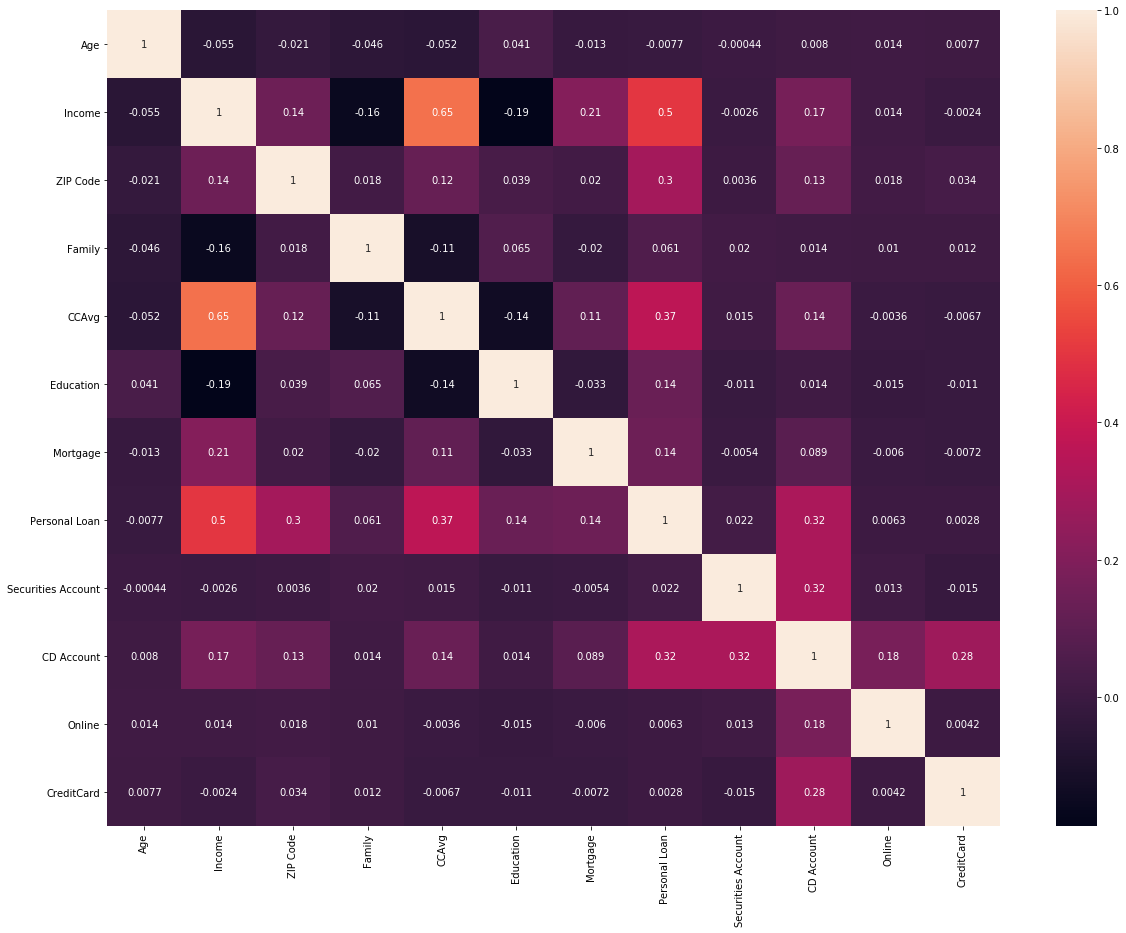

In [317]:
#And thus the new visual correlation-heatmap won't show "significant"(threshold 0.95?)
#"white-patches" aprt from the main digonal(self)
pyplot.subplots(figsize=(20,15))
sns.heatmap(new_customer_df.corr(), annot=True)

## Question 2

Get the target column distribution. Your comments (5 points)

In [318]:
#The response variable "Personal Loan" is distributed in the following way across 1 & 0s.
#i.e. the 9.6 % out of the 5000 who accepted the personal loan(i.e. the minority class, which
#could be converted to the asset-class)
new_customer_df['Personal Loan'].value_counts()

0    4520
1     480
Name: Personal Loan, dtype: int64

In [319]:
#Another way to look at the target column which is 'Personal Loan' distribution
new_customer_df.groupby(["Personal Loan"]).count()

,Age,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Securities Account,CD Account,Online,CreditCard
Personal Loan,,,,,,,,,,,
0,4520,4520,4520,4520,4520,4520,4520,4520,4520,4520,4520
1,480,480,480,480,480,480,480,480,480,480,480


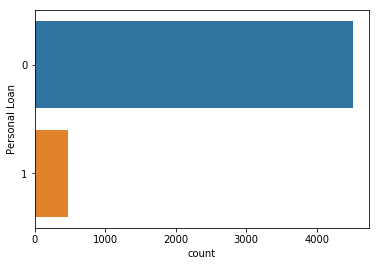

In [320]:
#Yet another way to look at it may be
plot = sns.countplot(y = "Personal Loan", data = new_customer_df)
plot.set_yticklabels(plot.get_yticklabels());

## Question 3

Split the data into training and test set in the ratio of 70:30 respectively ( 5 points)

In [321]:
# splitting data into training and test set for independent attributes
from sklearn.model_selection import train_test_split

X =  new_customer_df.drop("Personal Loan", axis=1)
y =  new_customer_df.pop("Personal Loan")

train_set, test_set, train_labels, test_labels = train_test_split(X, y, test_size=0.30, random_state=2)

In [322]:
X.head()

,Age,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Securities Account,CD Account,Online,CreditCard
ID,,,,,,,,,,,
1,25,49,0.12,4,1.60,1,0,1,0,0,0
2,45,34,0.17,3,1.50,1,0,1,0,0,0
3,39,11,0.11,1,1.00,1,0,0,0,0,0
4,35,100,0.00,1,2.70,2,0,0,0,0,0
5,35,45,0.07,4,1.00,2,0,0,0,0,1


In [323]:
#The actual 1's and 0s in this split are as follows(5000*0.3= 1500)
#i.e. 138 1s and 1362 0s
test_labels.value_counts()

0    1362
1     138
Name: Personal Loan, dtype: int64

**The test split above is shown to meet the demand of the above question-3, below will be using a routine to go thru the 3 required models, and the test-train-split is taken care inherently within the routine, with X & y used from above for each**

## Question 4

Use different classification models (Logistic, K-NN and Naïve Bayes) to predict the likelihood of a liability customer buying personal loans (25 points)

In [355]:
from sklearn.linear_model import LogisticRegression
#More of the features here are having a gaussian distribution
#hence for NB model, GaussianNB is selected
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn import model_selection

In [325]:
# calculate accuracy measures and confusion matrix
from sklearn import metrics
from sklearn.metrics import accuracy_score, confusion_matrix, recall_score, precision_score, f1_score, auc
from sklearn.metrics import roc_curve, auc

In [384]:
#Logistic Regression Model Instantiation
lrModel = LogisticRegression()
#KNN Model Instantiation(here the features are 11 in number
#hence sqrt(11) ~= 3.31-> or k=3)
knn = KNeighborsClassifier(n_neighbors=3)
#Naive Bayes Model Instantiation
nbModel = GaussianNB()

In [385]:
#Below routine provides the training & test set performance-assesments of any model
def modelPerformanceAnalysis(X, y, model, test_size = 0.3, seed = 7):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=seed)
    model.fit(X_train, y_train)
    ### Unoptimized probability threshold based performance numbers
    # Train accuracy numbers
    trainPreds = model.predict(X_train)
    trainAccuracy = accuracy_score(y_train, trainPreds)
    trainRecall = recall_score(y_train, trainPreds)
    trainPrecision = precision_score(y_train, trainPreds)
    trainF1score = f1_score(y_train, trainPreds)
    trainResults=[X_train.shape[0], trainAccuracy, trainRecall, trainPrecision, trainF1score]
    # Test accuracy numbers
    testPreds = model.predict(X_test)
    testAccuracy = accuracy_score(y_test, testPreds)
    testRecall = recall_score(y_test, testPreds)
    testPrecision = precision_score(y_test, testPreds)
    testF1score = f1_score(y_test, testPreds)
    testResults=[X_test.shape[0], testAccuracy, testRecall, testPrecision, testF1score]
    resultsDf = pd.DataFrame( index=["dataSize", "accuracy", "recall", "precision", "f1_score"])# Concatenate Train and Test results to resultsDf
    resultsDf['trainResults'] = trainResults
    resultsDf['testResults'] = testResults
    cm = pd.crosstab(y_test, testPreds, rownames=['Actual'], colnames=['Predicted'], margins=True)
    print("Confusion Matrix represented as crosstab is:")
    print(cm)
    return resultsDf.round(2)

In [386]:
modelPerformanceAnalysis(X, y, lrModel, 0.3, 7)

Confusion Matrix represented as crosstab is:
Predicted     0    1   All
Actual                    
0          1345   17  1362
1            47   91   138
All        1392  108  1500


,trainResults,testResults
dataSize,"3,500.00","1,500.00"
accuracy,0.96,0.96
recall,0.68,0.66
precision,0.86,0.84
f1_score,0.75,0.74


In [387]:
modelPerformanceAnalysis(X, y, nbModel, 0.3, 7)

Confusion Matrix represented as crosstab is:
Predicted     0    1   All
Actual                    
0          1241  121  1362
1            50   88   138
All        1291  209  1500


,trainResults,testResults
dataSize,"3,500.00","1,500.00"
accuracy,0.89,0.89
recall,0.60,0.64
precision,0.45,0.42
f1_score,0.51,0.51


In [388]:
#We have to convert the features into z scores, it is always adviced to scale numeric attributes
#in KNN models that calculate distances.
#For it we will require the follwoing import
from scipy.stats import zscore

In [389]:
# convert the features into z scores, 
X = X.apply(zscore)

In [390]:
modelPerformanceAnalysis(X, y, knn, 0.3, 7)

Confusion Matrix represented as crosstab is:
Predicted     0    1   All
Actual                    
0          1354    8  1362
1            39   99   138
All        1393  107  1500


,trainResults,testResults
dataSize,"3,500.00","1,500.00"
accuracy,0.98,0.97
recall,0.82,0.72
precision,0.98,0.93
f1_score,0.89,0.81


**Thus based on the above 3 model comparisons on this dataset, it looks like the likelihood of a liability customer buying personal loans, based on LR, NB & KNN models are 66%, 64% & 72 % respectively (based on the recall score)**

### Question 5

Print the confusion matrix for all the above models (10 points)

**The Confusion Matrix is printed for individual models as above in the Question-4**

## Question 6

Give your reasoning on which is the best model in this case and why it performs better? (10 points)

**Apart from the above performance-data under the question-4 & 5, the below cross-validation approach with "accuracy" as scoring criteria gives the follwoing numbers**

In [393]:
models = []
models.append(('LogisticRegression', lrModel))
models.append(('KNeighborsClassifier', knn))
models.append(('GaussianNB', nbModel))

In [394]:
# evaluate each model in turn
#using the k-fold cross validation
results = []
names = []
scoring = 'accuracy'
for name, model in models:
	kfold = model_selection.KFold(n_splits=4,random_state=0)
	cv_results = model_selection.cross_val_score(model, X, y, cv=kfold, scoring=scoring)
	results.append(cv_results)
	names.append(name)
	msg = "%s: %f (%f)" % (name, np.mean(cv_results), cv_results.var())
	print(msg)

LogisticRegression: 0.957000 (0.000002)
KNeighborsClassifier: 0.964200 (0.000014)
GaussianNB: 0.891000 (0.000023)


**The above gives a conclusion that the KNN has performed better than either LR and/or NB models for this dataset**

*The two main potential reasons that KNN in this case performs better is because:*

    a. irrespective of what ever distribution type of the features, KNN is the robust of other two (i.e. LR & NB) 
    
    b. There may be outliers in few of the above feature distributions, as discussed above, but KNN again is immune to them
    




# End Of Assignment